Libraries

In [23]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces

PDE and FD reference Parameters


In [24]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 30
T     = 0.6
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

Analytical diffusion solution


In [25]:
def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

FD For diffusion

In [26]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

__init__

In [27]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()                    # NEW

    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))   # NEW
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()
    def contains(self, x, t):                          # NEW
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
            if len(self._pts) < n:
                return None

            pts_arr  = np.asarray(self._pts)
            norm_arr = np.asarray(self._norm)

            mask = pts_arr[:, 1] < t_star
            if mask.sum() < n:
                return None

            norm_c = norm_arr[mask]
            pts_c  = pts_arr[mask]

            target = np.array([x_star / dx, t_star / dt])
            d2     = np.sum((norm_c - target) ** 2, axis=1)

            idx = np.argpartition(d2, n - 1)[:n]
            idx = idx[np.argsort(d2[idx])]

            return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

GFDM Solver


In [28]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if np.max(np.abs(w)) > 3.0 / len(dx_i):
        return None, 'weights'
    if np.min(w) < -1.0:
        return None, 'weights'

    return w, 'ok'

PDEEnvironment

In [29]:
class PDEEnvironment(gym.Env):

    def __init__(self, t_star_steps=2):
        super().__init__()

        #   PDE constants  
        self.alpha = alpha

        #G6id variables  
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T

        # ── Target point (z*) ───────────────────────────────────────────────────
        self.x_star = self.x_fd[self.nx // 2]
        self.t_star = t_star_steps * dt

        # ── RL parameters ───────────────────────────────────────────────────────
        self.K_max  = 500
        self.lam    = 0.005
        self.Kx     = 1
        self.Kt     = 1
        self.beta = 100.0

        # ── GFDM neighbours ─────────────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ───────────────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions ─────────────────────────────────────────────
        self.N = 10

        mid    = self.nx // 2
        margin = 8 
        half_n = self.N // 2
        step   = (mid - margin) / half_n if half_n > 0 else 0

        offsets = [0]
        k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1

        init_idx = np.clip(np.round(np.array(offsets[:self.N]) + mid).astype(int), margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]

        # ── FD reference built once ──────────────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ──────────────────────────────────
        self.visited     = None
        self.walker_x    = None
        self.walker_t    = None
        self.walker_u    = None
        self.step_count  = 0
        self.stencil_log = {}

        # ── Gym spaces ───────────────────────────────────────────────────────────
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(3 * self.N + 2,), dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete([self.N, 3, 2])


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.visited     = VisitedSet()
        self.stencil_log = {}

        # ── Seed with IC ─────────────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        # ── Seed with BCs ────────────────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        # ── Place walkers at t=0 ─────────────────────────────────────────────────
        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_init_x])

        self.step_count = 0

        return self._build_obs(), {}


    def _build_obs(self):
        return np.array([
            *self.walker_x,
            *self.walker_t,
            *self.walker_u,
            self.x_star,
            self.t_star
        ], dtype=np.float32)

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'

        nb   = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        if not (np.min(dx_i) < 0 < np.max(dx_i)):
            return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason

        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):

        self.step_count += 1
        done   = False
        reward = 0.0

        walker_idx, dx_idx, dt_idx = action
        i  = int(walker_idx)
        dx = (int(dx_idx) - self.Kx) * self.dx
        dt = int(dt_idx) * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx
        t_new = self.walker_t[i] + dt

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'

        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'

        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'] = reason
            else:
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True

                if (abs(x_new - self.x_star) < self.eps_x and
                    abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if done:
            u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
            u_ref           = u_true(self.x_star, self.t_star)

            if u_pred is None:
                reward        = -1.0
                info['error'] = None
            else:
                reward = -(self.beta * abs(u_pred - u_ref) + self.lam * self.step_count)
                info['u_pred'] = u_pred
                info['u_ref']  = u_ref
                info['error']  = abs(u_pred - u_ref)
                info['k_term'] = self.step_count

        elif self.step_count >= self.K_max:
            done = True
            reward = -1.0 - self.lam * self.step_count
            info['timeout'] = True

        return self._build_obs(), reward, done, False, info

Steps:          22
Reward:         -0.110556
Reached:        True
Timeout:        False
Total accepted: 14
Total rejected: 8
Rejection reasons:
  bounds    : 7
  collision : 1


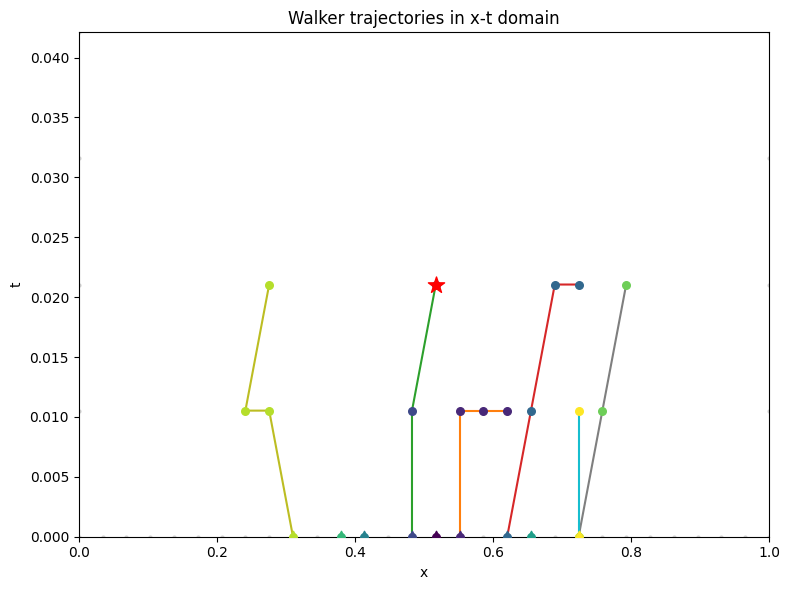

In [30]:
env      = PDEEnvironment()
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()                         # MultiDiscrete sample
    state, reward, done, _, info = env.step(action)

    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")
for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")

import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [31]:
def plot_trajectories(model, t_star_steps, save=True, timestep=None):
    env = PDEEnvironment(t_star_steps=t_star_steps)
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, zorder=2, color=colors[i])
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=5, label='z*')
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    ax.set_title(title)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)
    plt.tight_layout()

    if save:
        if timestep is not None:
            fname = f'traj_t{t_star_steps}dt_{timestep//1000:04d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt_{outcome}.png'
        fig.savefig(fname, dpi=120)

    plt.close(fig)

In [32]:
%matplotlib inline

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True


class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, plot_freq=50_000, verbose=0):
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.plot_freq    = plot_freq
        self.last_plot_at = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, save=True,
                              timestep=self.num_timesteps)
        return True


def make_env(t_star_steps):
    def _init():
        return Monitor(PDEEnvironment(t_star_steps=t_star_steps))
    return _init


curriculum   = [2, 3, 4, 5]
n_envs       = 15
n_steps      = 2048 // n_envs
timesteps_per_stage = 3_000_000

# build model on first stage
vec_env = SubprocVecEnv([make_env(curriculum[0]) for _ in range(n_envs)])
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    gamma=1.0,
    device="cpu",
    n_steps=n_steps,
    batch_size=60,
    tensorboard_log="./logs/",
)

for t_star_steps in curriculum:
    print(f"\n{'='*50}")
    print(f"Stage: t_star = {t_star_steps}·dt = {t_star_steps * dt:.4f}")
    print(f"{'='*50}")

    vec_env = SubprocVecEnv([make_env(t_star_steps) for _ in range(n_envs)])
    model.set_env(vec_env)

    model.learn(
        total_timesteps=timesteps_per_stage,
        reset_num_timesteps=False,
        tb_log_name="joint_curriculum",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(t_star_steps, plot_freq=50_000),
            CheckpointCallback(
                save_freq=100_000,
                save_path=f"./ckpts/tstar{t_star_steps}/",
                name_prefix=f"tstar{t_star_steps}"
            ),
        ],
    )

    model.save(f"checkpoint_tstar{t_star_steps}_final")
    print(f"Stage {t_star_steps} done — saved checkpoint_tstar{t_star_steps}_final")
    plot_trajectories(model, t_star_steps, save=True, timestep=timesteps_per_stage)

Using cpu device

Stage: t_star = 2·dt = 0.0211
Logging to ./logs/joint_curriculum_0
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 161          |
|    ep_rew_mean          | -1.02        |
|    mean_error_on_reach  | 1.81e-05     |
|    mean_kterm_on_reach  | 68.5         |
|    reached_rate         | 0.79         |
| time/                   |              |
|    fps                  | 2422         |
|    iterations           | 10           |
|    time_elapsed         | 8            |
|    total_timesteps      | 20400        |
| train/                  |              |
|    approx_kl            | 0.0072944146 |
|    clip_fraction        | 0.104        |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.91        |
|    explained_variance   | 0.681        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.115        |
|    n_updates            | 90           |
|    policy_

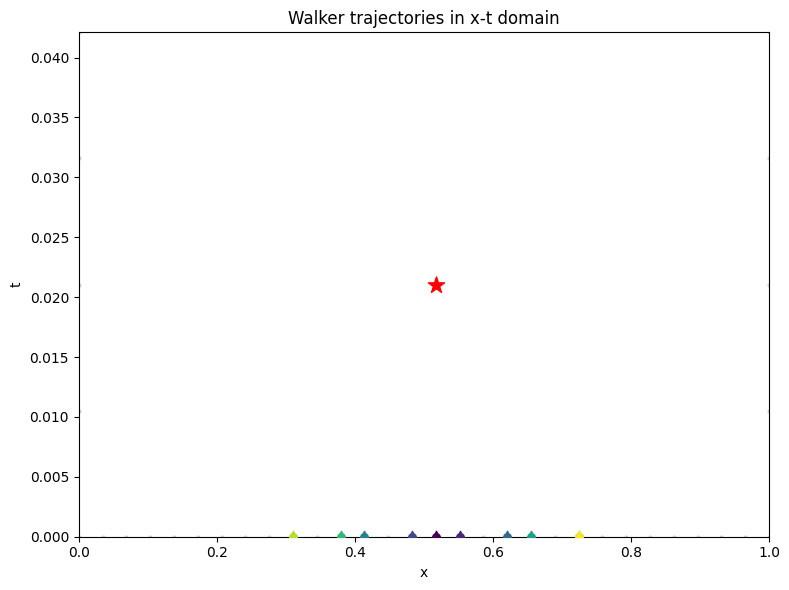

In [34]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
obs, _ = env.reset()
trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))
        
visited_log = [(x, t) for (x, t, _) in env.visited._pts]
fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-',  linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

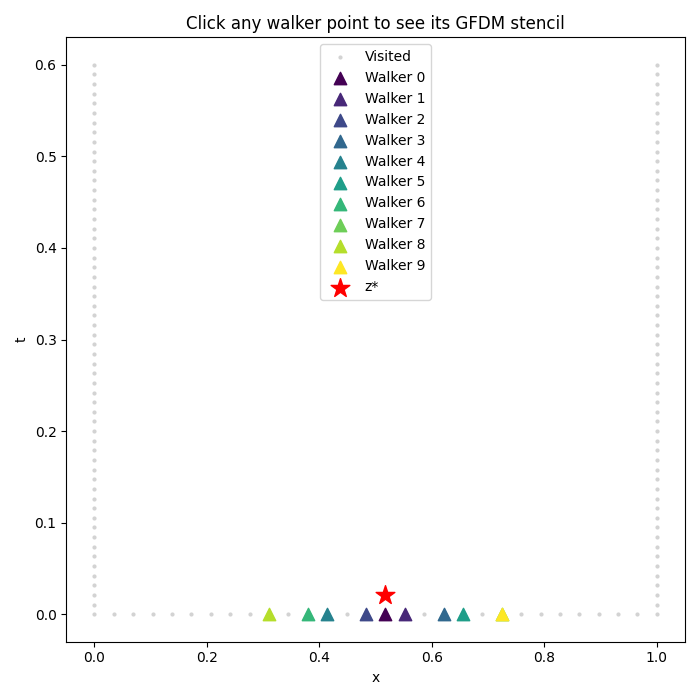

In [35]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Use logged stencils instead of post-hoc reconstruction ───────────────────
stencils = {key: coords for key, coords in env.stencil_log.items()}

# ── Build plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors     = cm.tab10.colors
all_points = []

for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-',  linewidth=1.5, zorder=2)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^',
               zorder=4, label=f'Walker {i}')
    for (x, t) in traj[1:]:
        ax.scatter(x, t, s=60, color=colors[i], zorder=3)
        all_points.append((x, t, i))

ax.scatter(env.x_star, env.t_star, s=200, color='red',
           marker='*', zorder=5, label='z*')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Click any walker point to see its GFDM stencil')
ax.legend()
plt.tight_layout()

active_lines = []

def on_click(event):
    global active_lines

    if event.inaxes != ax or not all_points:
        return

    cx, ct  = event.xdata, event.ydata
    best_pt = min(all_points,
                  key=lambda p: ((p[0]-cx)/env.dx)**2 + ((p[1]-ct)/env.dt)**2)
    x, t, i = best_pt
    key     = (round(x, 8), round(t, 8))

    for line in active_lines:
        line.remove()
    active_lines = []

    if key in stencils:
        for (nx, nt) in stencils[key]:
            colors = plt.cm.viridis(np.linspace(0, 1, env.N))
            line, = ax.plot([x, nx], [t, nt], '--' , alpha=0.75,
                            linewidth=2, zorder=2)
            active_lines.append(line)

        dot, = ax.plot(x, t, 'o',
                       markersize=10, markeredgecolor='black',
                       markeredgewidth=1.5, zorder=6)
        active_lines.append(dot)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

In [36]:
env = PDEEnvironment()
env.reset()

# Force specific known actions and check they decode correctly
test_actions = [
    [0, 0, 1],   # walker 0, dx=-dx, dt=+dt  — should move left+forward
    [0, 2, 1],   # walker 0, dx=+dx, dt=+dt  — should move right+forward
    [0, 1, 0],   # walker 0, dx=0,   dt=0    — always rejected (no-op)
    [5, 2, 1],   # walker 5, dx=+dx, dt=+dt
]

for a in test_actions:
    env.reset()
    obs, reward, done, _, info = env.step(a)
    print(f"action={a} | walker={info['walker']} | accepted={info['accepted']} | rejected={info['rejected']}")
    if info['accepted']:
        i = info['walker']
        print(f"  → walker {i} now at x={env.walker_x[i]:.4f}, t={env.walker_t[i]:.4f}")

action=[0, 0, 1] | walker=0 | accepted=True | rejected=None
  → walker 0 now at x=0.4828, t=0.0105
action=[0, 2, 1] | walker=0 | accepted=True | rejected=None
  → walker 0 now at x=0.5517, t=0.0105
action=[0, 1, 0] | walker=0 | accepted=False | rejected=bounds
action=[5, 2, 1] | walker=5 | accepted=True | rejected=None
  → walker 5 now at x=0.6897, t=0.0105


In [38]:
import os
files = sorted(os.listdir("./ckpts/tstar2/"))
for f in files:
    print(f)

tstar2_1500000_steps.zip
tstar2_3000000_steps.zip
